In [310]:
import pandas as pd
import missingno as msno
from sklearn.model_selection import train_test_split
from missforest import MissForest
from sklearn.ensemble import IsolationForest
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.inspection import permutation_importance
import shap
import lightgbm as lgb
import numpy as np
from statsmodels.stats.outliers_influence import variance_inflation_factor
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_val_score

In [311]:
df=pd.read_csv("/workspaces/jovegom-intro-ml/data/bank-marketing-campaign-data.csv",sep=';')
df=df.rename(columns={'marital':'estado_civil','default':'tiene_credito','housing':'credito_vivienda','loan':'credito_persoanl','month':'ulti_mes_contac','day_of_week':'ultimo_dia_contac','duration':'duracion_contac','campaign':'n_contac','y':'deposito_largo_plazo'})

In [312]:
df

,age,job,estado_civil,education,tiene_credito,credito_vivienda,credito_persoanl,contact,ulti_mes_contac,ultimo_dia_contac,duracion_contac,n_contac,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,deposito_largo_plazo
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.100,93.994,-36.400,4.857,5191.000,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.100,93.994,-36.400,4.857,5191.000,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.100,93.994,-36.400,4.857,5191.000,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.100,93.994,-36.400,4.857,5191.000,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.100,93.994,-36.400,4.857,5191.000,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,334,1,999,0,nonexistent,-1.100,94.767,-50.800,1.028,4963.600,yes
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,383,1,999,0,nonexistent,-1.100,94.767,-50.800,1.028,4963.600,no
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,189,2,999,0,nonexistent,-1.100,94.767,-50.800,1.028,4963.600,no
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,442,1,999,0,nonexistent,-1.100,94.767,-50.800,1.028,4963.600,yes


# Identificamos valores unicos

In [313]:
valores_unicos=df.nunique()
valores_unicos

age                       78
job                       12
estado_civil               4
education                  8
tiene_credito              3
credito_vivienda           3
credito_persoanl           3
contact                    2
ulti_mes_contac           10
ultimo_dia_contac          5
duracion_contac         1544
n_contac                  42
pdays                     27
previous                   8
poutcome                   3
emp.var.rate              10
cons.price.idx            26
cons.conf.idx             26
euribor3m                316
nr.employed               11
deposito_largo_plazo       2
dtype: int64

No tenemos valores unicos

# Filas y columnas duplicadas

In [314]:
# Filas duplicadas
df.duplicated().sum()

np.int64(12)

In [315]:
# Tenemos 12 duplicados los cuales eliminamos
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

In [316]:
df.T.duplicated().sum()

np.int64(0)

No tenemos columnas duplicadas

# Valores Faltantes

In [317]:
promedio_faltantes=df.isna().mean()*100
faltantes = ["no hay valores faltantes"] if any(n == 0 for n in promedio_faltantes) else promedio_faltantes
faltantes


['no hay valores faltantes']

## Valores faltantes enmascarados   

In [318]:
# traemos el Df con solo columnas categoricas
df_cate = df.select_dtypes(include=['object'])
# sacamos la cantidad de unknown por columna
unknown_counts = df_cate.apply(lambda col: (col == "unknown").sum())
# sacamos el porcentaje de unknown
unknown_porce= df_cate.apply(lambda col: (col == "unknown").mean()*100)
# creamos un DF con esta info
df_result=pd.DataFrame({'unknown_counts':unknown_counts,'unknown_porcentaje':unknown_porce}).sort_values(by='unknown_counts',ascending=False)
df_result

,unknown_counts,unknown_porcentaje
tiene_credito,8596,20.876
education,1730,4.201
credito_vivienda,990,2.404
credito_persoanl,990,2.404
job,330,0.801
estado_civil,80,0.194
contact,0,0.000
ulti_mes_contac,0,0.000
ultimo_dia_contac,0,0.000
poutcome,0,0.000


deacuerdo a lo anterior se decide eliminar los datos que tienen menos del 1% y se pone en consideracion mas adelante los que tienen un 2.4%

In [319]:
df_cate = df.select_dtypes(include=['object'])
# sacamos la cantidad de unknown por columna
nonexistent_counts = df_cate.apply(lambda col: (col == "nonexistent").sum())
# sacamos el porcentaje de unknown
nonexistent_porce= df_cate.apply(lambda col: (col == "nonexistent").mean()*100)
# creamos un DF con esta info
df_result=pd.DataFrame({'nonexistent_counts':nonexistent_counts,'nonexistent_porcentaje':nonexistent_porce}).sort_values(by='nonexistent_counts',ascending=False)
df_result

,nonexistent_counts,nonexistent_porcentaje
poutcome,35551,86.339
estado_civil,0,0.000
job,0,0.000
education,0,0.000
tiene_credito,0,0.000
credito_persoanl,0,0.000
credito_vivienda,0,0.000
contact,0,0.000
ulti_mes_contac,0,0.000
ultimo_dia_contac,0,0.000


Eliminamos la columna poutcome, ya que en su mayoria no posee datos que nos aporte al modelo

In [320]:
df = df.drop('poutcome', axis=1)

In [321]:
df=df[df['job']!='unknown']
df=df[df['estado_civil']!='unknown']
unknown_counts = df[['job','estado_civil']].apply(lambda col: (col == "unknown").sum())
unknown_counts

job             0
estado_civil    0
dtype: int64

<Axes: >

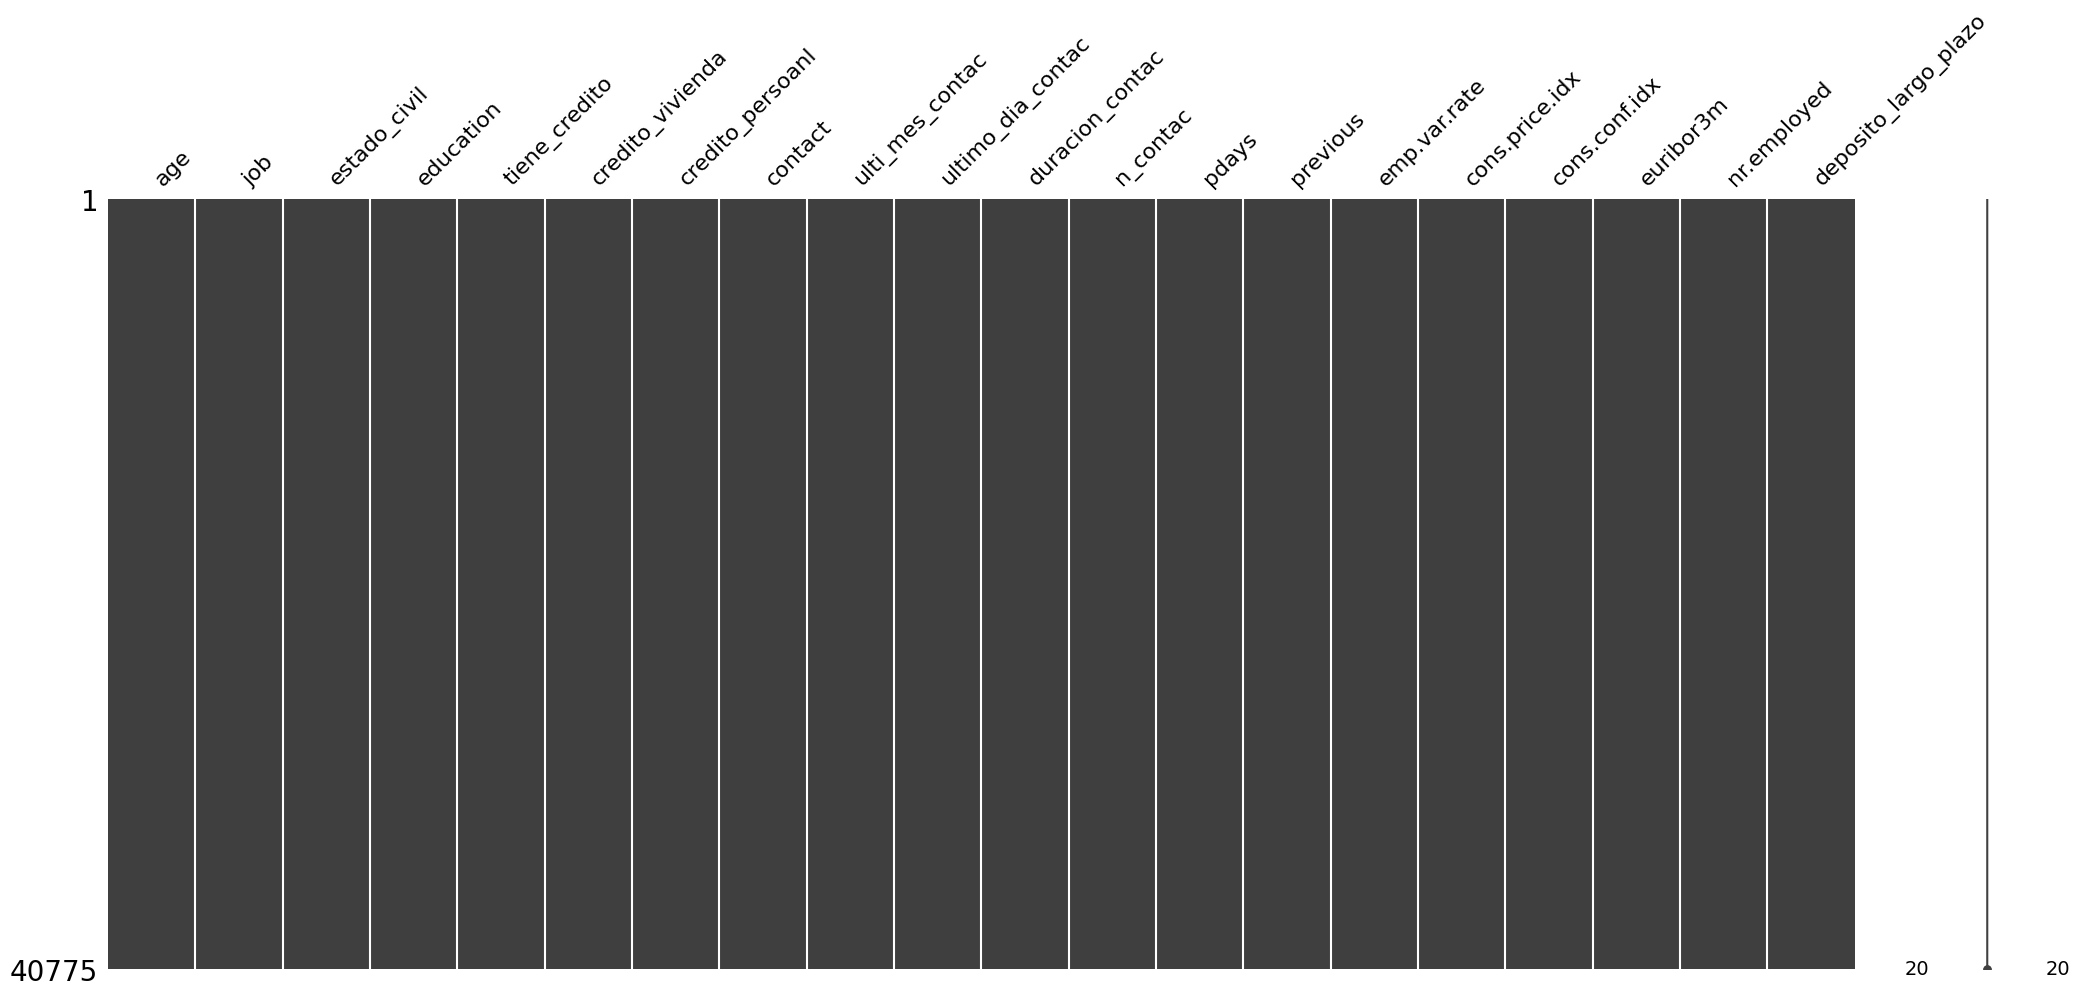

In [322]:
msno.matrix(df)

# Codificar variables categóricas.

In [323]:

# Identificar columnas categóricas
cat_cols = df.select_dtypes(include=['object']).columns

# Contar categorías por columna
num_categories = df[cat_cols].nunique()

# Dividir columnas según número de categorías
onehot_cols = num_categories[num_categories <= 4].index.tolist()
freq_cols   = num_categories[num_categories > 4].index.tolist()

# Aplicar one-hot encoding a las columnas pequeñas
df_onehot = pd.get_dummies(df[onehot_cols], drop_first=True, dtype=int)

# Aplicar frequency encoding a las columnas grandes
df_freq = df[freq_cols].copy()
for col in df_freq.columns:
    freq = df_freq[col].value_counts()
    df_freq[col] = df_freq[col].map(freq)

# Combinar todo con las columnas numéricas restantes
num_cols = df.select_dtypes(exclude=['object']).columns
df = pd.concat([df[num_cols], df_onehot, df_freq], axis=1)


# Train test split

In [324]:
X= df.drop('deposito_largo_plazo_yes',axis=1)
y= df['deposito_largo_plazo_yes']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Outliers

In [325]:
pd.set_option('display.float_format', '{:.3f}'.format)
X_train.describe().T

,count,mean,std,min,25%,50%,75%,max
age,32620.000,39.972,10.382,17.000,32.000,38.000,47.000,98.000
duracion_contac,32620.000,258.068,258.170,0.000,102.000,179.000,320.000,3785.000
n_contac,32620.000,2.576,2.763,1.000,1.000,2.000,3.000,56.000
pdays,32620.000,962.808,186.086,0.000,999.000,999.000,999.000,999.000
previous,32620.000,0.171,0.489,0.000,0.000,0.000,0.000,6.000
emp.var.rate,32620.000,0.084,1.570,-3.400,-1.800,1.100,1.400,1.400
cons.price.idx,32620.000,93.576,0.578,92.201,93.075,93.749,93.994,94.767
cons.conf.idx,32620.000,-40.526,4.625,-50.800,-42.700,-41.800,-36.400,-26.900
euribor3m,32620.000,3.622,1.734,0.634,1.344,4.857,4.961,5.045
nr.employed,32620.000,5167.191,72.170,4963.600,5099.100,5191.000,5228.100,5228.100


In [326]:
iso = IsolationForest(random_state=123)
df_num = X_train.copy()
df_num['outlier_flag'] = iso.fit_predict(X_train)
df_num['outlier_flag'].value_counts()

outlier_flag
 1    22455
-1    10165
Name: count, dtype: int64

# Seleccion de caracteristicas

## Método 1 Feature importance de RF

In [327]:
# Entrenamiento de RF
model = RandomForestRegressor(random_state=42,n_jobs=-1).fit(X_train, y_train)
# Importancia de características
importances = model.feature_importances_/model.feature_importances_.sum()*100
# Convertir a DataFrame
df_rf_imp = pd.DataFrame({'feature': X_train.columns,'rf_importance': importances}).sort_values(by='rf_importance', ascending=False)
# Calculamos la importancia acumulada
df_rf_imp['rf_importance_acum'] = df_rf_imp['rf_importance'].cumsum()
df_rf_imp

,feature,rf_importance,rf_importance_acum
1,duracion_contac,34.584,34.584
9,nr.employed,15.629,50.213
0,age,9.481,59.694
8,euribor3m,8.789,68.483
19,job,4.404,72.887
20,education,3.826,76.713
2,n_contac,3.761,80.473
22,ultimo_dia_contac,3.354,83.827
21,ulti_mes_contac,2.963,86.791
3,pdays,2.807,89.597


## Metodo 2 Permutation/Shuffle importance

In [328]:
# Para esta técnica y la de shap se necesita conjunto de validación
X_train1, X_val, y_train1, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

# Ajustamos el modelo
model_xgb = XGBRegressor(objective='reg:squarederror', random_state=42).fit(X_train1, y_train1)

# Realizamos 10 permutaciones por cada característica (se usa neg_mean_absolute_error)
perm = permutation_importance(model_xgb, X_val, y_val, n_repeats=10, random_state=42, n_jobs=-1, scoring='neg_mean_absolute_error')

df_perm_imp = pd.DataFrame({'feature': X_train.columns, 'perm_imp': perm.importances_mean*100}).sort_values('perm_imp', ascending=False)
df_perm_imp

,feature,perm_imp
1,duracion_contac,4.831
9,nr.employed,2.621
21,ulti_mes_contac,2.587
8,euribor3m,2.176
5,emp.var.rate,1.388
6,cons.price.idx,0.867
3,pdays,0.615
7,cons.conf.idx,0.540
0,age,0.437
18,contact_telephone,0.315


## Metodo 3 SHAP

In [329]:
# Ajustamos el modelo
model_lgbm = lgb.LGBMRegressor(random_state=42, n_jobs=-1).fit(X_train, y_train)

explainer = shap.Explainer(model_lgbm, X_val)   # usa el mismo X_val
shap_vals = explainer(X_val).values

imp_shap = np.abs(shap_vals).mean(axis=0)
imp_shap_pct = imp_shap/imp_shap.sum()*100
df_shap_imp = pd.DataFrame({"feature": X_val.columns, "shap_imp": imp_shap_pct}).sort_values('shap_imp', ascending=False)
df_shap_imp

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.090623 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 726
[LightGBM] [Info] Number of data points in the train set: 32620, number of used features: 22
[LightGBM] [Info] Start training from score 0.111925


 91%|==================  | 5915/6524 [00:11<00:01]       

,feature,shap_imp
1,duracion_contac,37.089
21,ulti_mes_contac,16.465
9,nr.employed,14.483
8,euribor3m,9.040
5,emp.var.rate,4.059
0,age,3.143
18,contact_telephone,2.204
3,pdays,2.186
12,tiene_credito_unknown,1.936
6,cons.price.idx,1.586


## Union de metodos

In [330]:
df_importances = (
    df_rf_imp
    .merge(df_perm_imp, on='feature', how='outer')
    .merge(df_shap_imp, on='feature', how='outer')
).sort_values('rf_importance', ascending=False)
df_importances

,feature,rf_importance,rf_importance_acum,perm_imp,shap_imp
8,duracion_contac,34.584,34.584,4.831,37.089
16,nr.employed,15.629,50.213,2.621,14.483
0,age,9.481,59.694,0.437,3.143
13,euribor3m,8.789,68.483,2.176,9.040
14,job,4.404,72.887,0.283,0.818
9,education,3.826,76.713,0.110,1.215
15,n_contac,3.761,80.473,0.143,1.313
22,ultimo_dia_contac,3.354,83.827,0.314,1.583
21,ulti_mes_contac,2.963,86.791,2.587,16.465
17,pdays,2.807,89.597,0.615,2.186


# Caracteristicas seleccionadas

In [331]:
df_filt = df_importances[(df_importances['rf_importance']>=1)|(df_importances['perm_imp']>=1)|(df_importances['shap_imp']>=1)]
df_filt

,feature,rf_importance,rf_importance_acum,perm_imp,shap_imp
8,duracion_contac,34.584,34.584,4.831,37.089
16,nr.employed,15.629,50.213,2.621,14.483
0,age,9.481,59.694,0.437,3.143
13,euribor3m,8.789,68.483,2.176,9.040
14,job,4.404,72.887,0.283,0.818
9,education,3.826,76.713,0.110,1.215
15,n_contac,3.761,80.473,0.143,1.313
22,ultimo_dia_contac,3.354,83.827,0.314,1.583
21,ulti_mes_contac,2.963,86.791,2.587,16.465
17,pdays,2.807,89.597,0.615,2.186


## VIF

In [332]:
features = df_filt['feature']
features

8           duracion_contac
16              nr.employed
0                       age
13                euribor3m
14                      job
9                 education
15                 n_contac
22        ultimo_dia_contac
21          ulti_mes_contac
17                    pdays
18                 previous
7      credito_vivienda_yes
2            cons.price.idx
5      credito_persoanl_yes
1             cons.conf.idx
3         contact_telephone
19    tiene_credito_unknown
10             emp.var.rate
Name: feature, dtype: object

In [333]:
vif = pd.Series([variance_inflation_factor(X_train[features].corr().values, i) for i in range(X_train[features].corr().shape[1])], index=X_train[features].columns)
df_vif = pd.Series(vif, name='vif').reset_index().rename(columns={'index': 'feature'})
df_vif

,feature,vif
0,duracion_contac,1.119
1,nr.employed,8884.719
2,age,1.514
3,euribor3m,24733.602
4,job,1.407
5,education,1.448
6,n_contac,2.077
7,ultimo_dia_contac,1.080
8,ulti_mes_contac,19.052
9,pdays,6.002


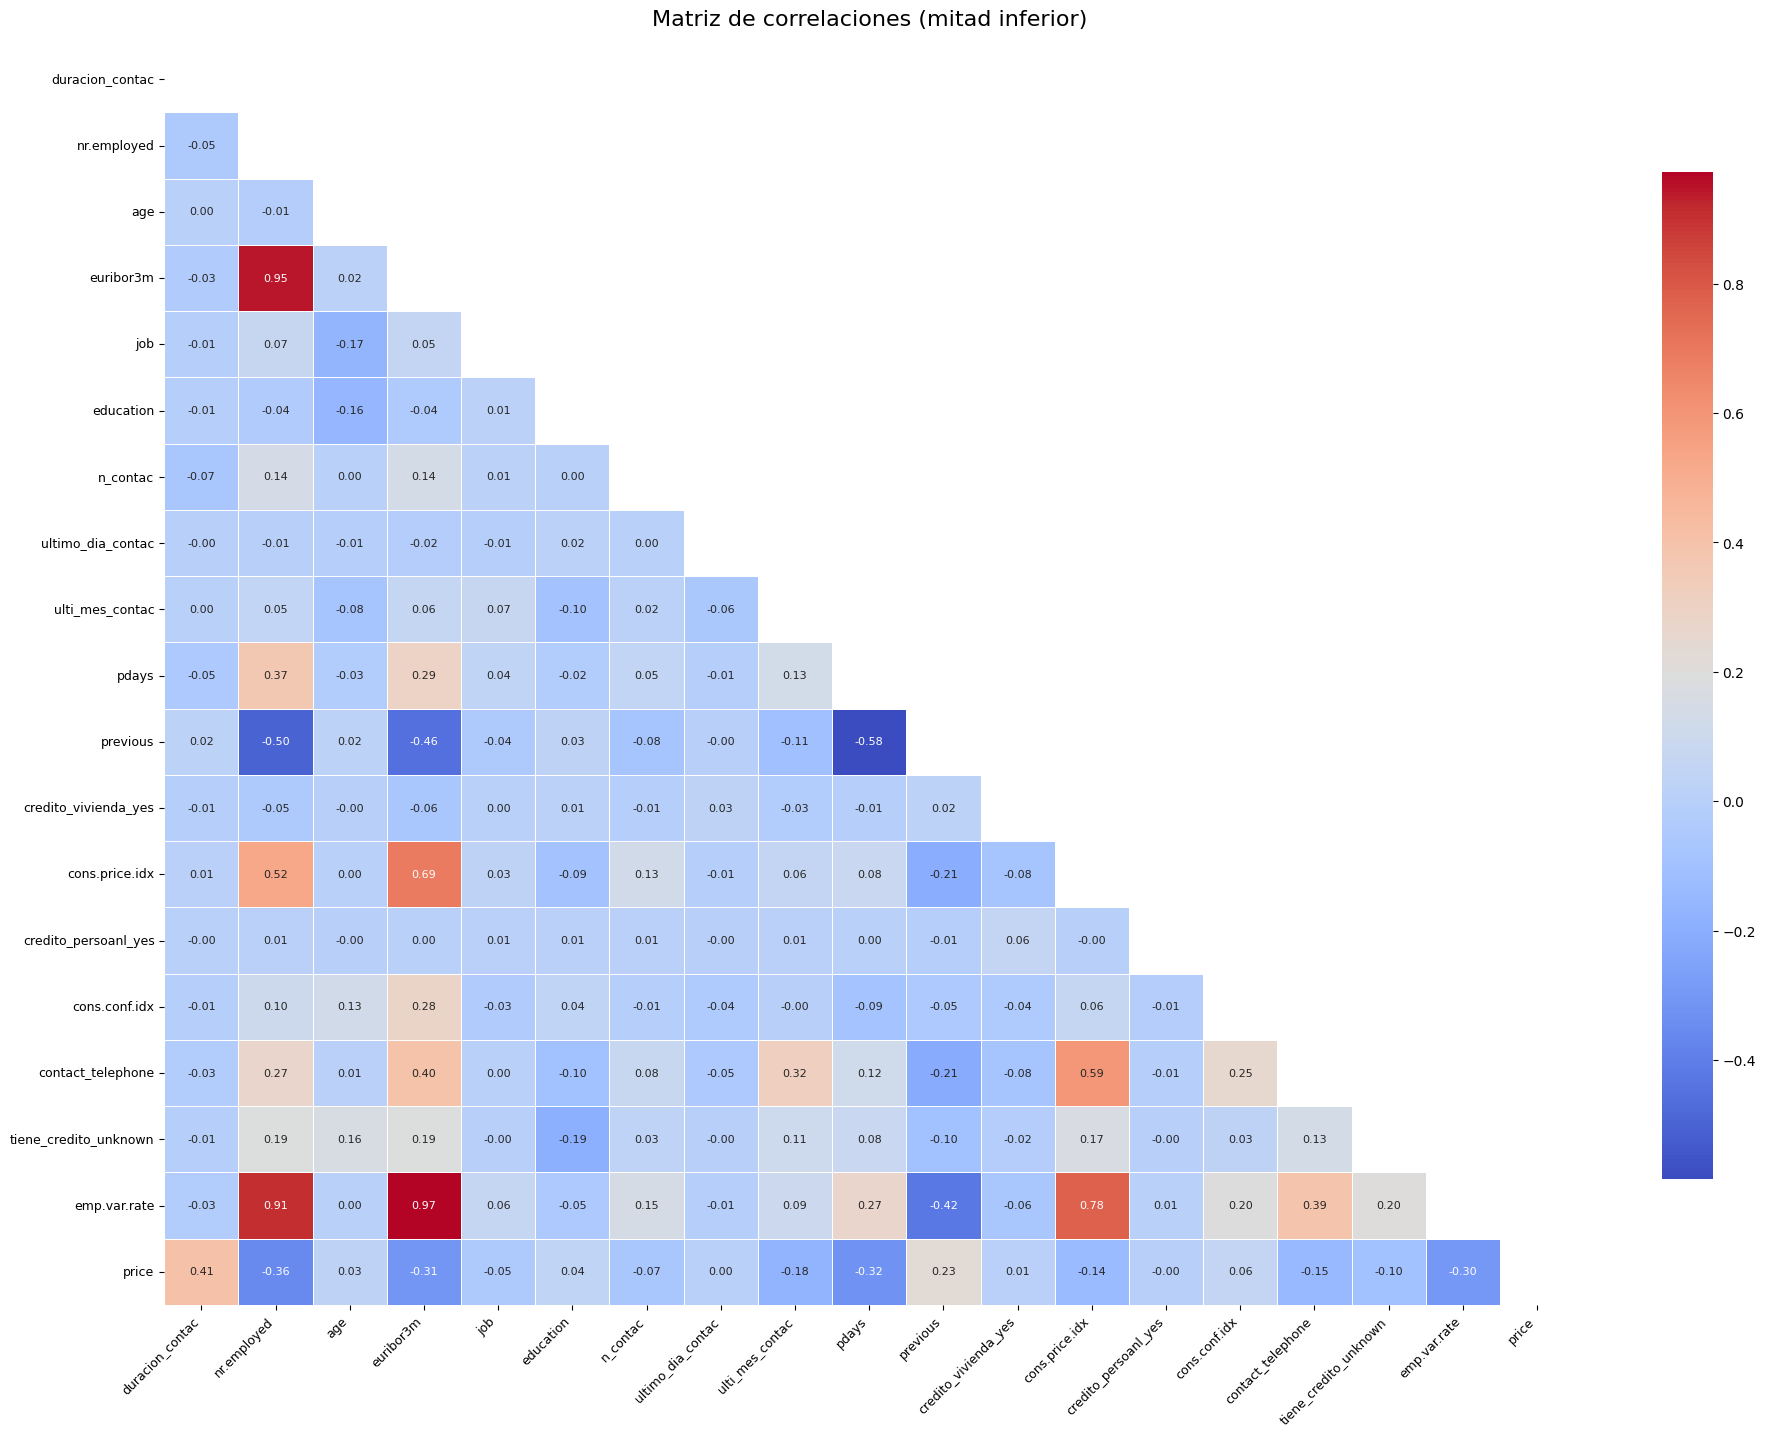

In [334]:
X_copy = X_train[features].copy()
X_copy['price'] = y_train
corr = X_copy.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(20, 15))
sns.heatmap(
    corr, mask=mask, cmap='coolwarm',
    annot=True, fmt=".2f", linewidths=.5,
    cbar_kws={"shrink": .8},
    annot_kws={"size": 8}
)
plt.title("Matriz de correlaciones (mitad inferior)", fontsize=16, pad=15)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout(pad=3.0)
plt.show()

## Cross_validation

In [341]:
# Versión 1: Realizar cross_validation con todas las características que son candidatas
cv_results1 = cross_val_score(RandomForestRegressor(random_state=42,n_jobs=-1), X_train[features], y_train, cv=3, scoring='neg_mean_absolute_percentage_error')
cv_results1.mean()*-1

np.float64(256116946918488.03)

In [342]:
# Versión 2: Realizar cross_validation con  las características que son candidatas sin las correlacionadas
cv_results2 = cross_val_score(RandomForestRegressor(random_state=42,n_jobs=-1), X_train[features].drop(['emp.var.rate'],axis=1), y_train, cv=3, scoring='neg_mean_absolute_percentage_error')
cv_results2.mean()*-1

np.float64(256790723751090.88)

In [ ]:

pd.set_option('display.max_columns', None)
df

,age,duracion_contac,n_contac,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,estado_civil_married,estado_civil_single,tiene_credito_unknown,tiene_credito_yes,credito_vivienda_unknown,credito_vivienda_yes,credito_persoanl_unknown,credito_persoanl_yes,contact_telephone,deposito_largo_plazo_yes,job,education,ulti_mes_contac,ultimo_dia_contac
0,56,261,1,999,0,1.100,93.994,-36.400,4.857,5191.000,1,0,0,0,0,0,0,0,1,0,1057,4118,13617,8418
1,57,149,1,999,0,1.100,93.994,-36.400,4.857,5191.000,1,0,1,0,0,0,0,0,1,0,3961,9461,13617,8418
2,37,226,1,999,0,1.100,93.994,-36.400,4.857,5191.000,1,0,0,0,0,1,0,0,1,0,3961,9461,13617,8418
3,40,151,1,999,0,1.100,93.994,-36.400,4.857,5191.000,1,0,0,0,0,0,0,0,1,0,10405,2263,13617,8418
4,56,307,1,999,0,1.100,93.994,-36.400,4.857,5191.000,1,0,0,0,0,0,0,1,1,0,3961,9461,13617,8418
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,334,1,999,0,-1.100,94.767,-50.800,1.028,4963.600,1,0,0,0,0,1,0,0,0,1,1713,5222,4086,7778
41184,46,383,1,999,0,-1.100,94.767,-50.800,1.028,4963.600,1,0,0,0,0,0,0,0,0,0,9239,5222,4086,7778
41185,56,189,2,999,0,-1.100,94.767,-50.800,1.028,4963.600,1,0,0,0,0,1,0,0,0,0,1713,12092,4086,7778
41186,44,442,1,999,0,-1.100,94.767,-50.800,1.028,4963.600,1,0,0,0,0,0,0,0,0,1,6727,5222,4086,7778
